In [468]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
from sdv.metadata import SingleTableMetadata
# from sdv.single_table import CopulaGANSynthesizer, TVAESynthesizer, CTGANSynthesizer
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans


import optuna

device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

In [469]:
data = pd.read_csv('train_data.csv')
data = data.drop(['Этаж', 'Район', 'id', 'date', 'rooms', 'Цена', 'nprice'], axis=1)
data['day'] = pd.to_datetime(data['day'])
data['date'] = data['day']
data['month'] = data['day'].dt.month
data['year'] = data['day'].dt.year
data['day'] = data['day'].dt.day
data = data.dropna()

data = data.sort_values(by='date').reset_index(drop=True)
data = data.drop('date', axis=1)

data = pd.concat([data.drop('pricemetr', axis=1), data['pricemetr']], axis=1)

feat_name = 'floor'
# data = pd.concat([data[feat_name], data.drop(feat_name, axis=1)], axis=1)



cat_cols_name = np.array(['day', 'количество этажей всего', 'Этажность объекта подземная',\
                'Этажность объекта наземная', 'Квартиры среднего качества (типовые)', 'month', 'year'])
cat_cols_name_w_feat = np.hstack([[feat_name], cat_cols_name])

num_cols_name = np.setdiff1d(data.columns, cat_cols_name)
num_cols_name = np.setdiff1d(num_cols_name, [feat_name, 'pricemetr'])
num_cols_name_w_feat = np.hstack([num_cols_name, ['pricemetr']])

data = pd.concat([data[np.hstack(['floor', cat_cols_name])], data[np.hstack([num_cols_name, 'pricemetr'])]], axis=1)

In [470]:
length_num = len(num_cols_name)
length_cat = len(cat_cols_name)

In [471]:
# data.drop(['floor', 'pricemetr'], axis=1).iloc[:, length_cat:]

In [472]:
data.head()

,floor,day,количество этажей всего,Этажность объекта подземная,Этажность объекта наземная,Квартиры среднего качества (типовые),month,year,cemetprox,daycos,...,medprox,metroprox,rwprox,schoolprox,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,Площадь квартиры,высота объекта,pricemetr
0,6.0,9,10.0,1.0,12.0,1.794581,1,2017,0.025636,0.988023,...,0.013445,0.032267,0.063012,0.002639,105.0,14021.45,10127.91,74.54,39.77,0.080756
1,9.0,9,10.0,1.0,12.0,1.794581,1,2017,0.025636,0.988023,...,0.013445,0.032267,0.063012,0.002639,105.0,14021.45,10127.91,51.14,39.77,0.089729
2,1.0,11,7.0,1.0,7.0,1.794581,1,2017,0.030034,0.982126,...,0.020446,0.213776,0.006572,0.022235,382.0,17592.80,15221.76,27.92,26.00,0.150468
3,3.0,11,7.0,1.0,7.0,1.794581,1,2017,0.030034,0.982126,...,0.020446,0.213776,0.006572,0.022235,382.0,17592.80,15221.76,38.89,26.00,0.157270
4,12.0,11,18.0,2.0,16.0,1.794581,1,2017,0.020048,0.982126,...,0.011989,0.008984,0.004219,0.003442,377.0,47872.00,21659.00,28.00,63.90,0.363360


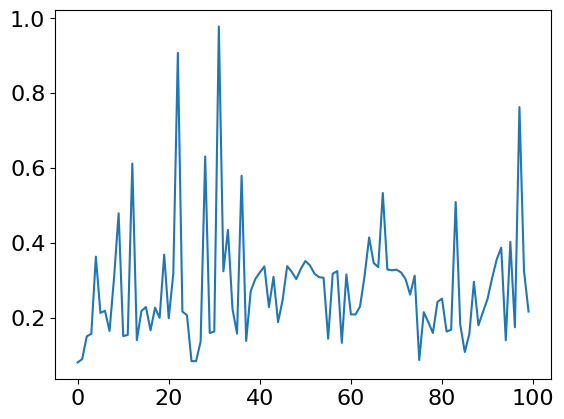

In [473]:
plt.plot(data['pricemetr'].iloc[:100])
plt.show()

In [474]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import shap

In [475]:
data_unnormalized = copy.deepcopy(data)

In [476]:
# X, y = data.drop('pricemetr', axis=1), data['pricemetr']

In [478]:
scaler_num = MinMaxScaler()
scaler_cat = MinMaxScaler()
label_encoder = LabelEncoder()

data_unnormalized[num_cols_name_w_feat] = scaler_num.fit_transform(data_unnormalized[num_cols_name_w_feat])

label_encoders_arr = []
for col in cat_cols_name:
    label_encoder = LabelEncoder()
    data_unnormalized[col] = label_encoder.fit_transform(data_unnormalized[col])
    label_encoders_arr.append(label_encoder)
    

data[num_cols_name_w_feat] = scaler_num.transform(data[num_cols_name_w_feat])
data[cat_cols_name_w_feat] = scaler_cat.fit_transform(data[cat_cols_name_w_feat])

In [482]:
data.head()

,floor,day,количество этажей всего,Этажность объекта подземная,Этажность объекта наземная,Квартиры среднего качества (типовые),month,year,cemetprox,daycos,...,medprox,metroprox,rwprox,schoolprox,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,Площадь квартиры,высота объекта,pricemetr
0,0.065789,0.266667,0.100000,0.043478,0.127907,0.877598,0.0,0.0,0.025636,0.988023,...,0.013445,0.032267,0.063012,0.002639,105.0,14021.45,10127.91,74.54,39.77,0.080756
1,0.105263,0.266667,0.100000,0.043478,0.127907,0.877598,0.0,0.0,0.025636,0.988023,...,0.013445,0.032267,0.063012,0.002639,105.0,14021.45,10127.91,51.14,39.77,0.089729
2,0.000000,0.333333,0.066667,0.043478,0.069767,0.877598,0.0,0.0,0.030034,0.982126,...,0.020446,0.213776,0.006572,0.022235,382.0,17592.80,15221.76,27.92,26.00,0.150468
3,0.026316,0.333333,0.066667,0.043478,0.069767,0.877598,0.0,0.0,0.030034,0.982126,...,0.020446,0.213776,0.006572,0.022235,382.0,17592.80,15221.76,38.89,26.00,0.157270
4,0.144737,0.333333,0.188889,0.086957,0.174419,0.877598,0.0,0.0,0.020048,0.982126,...,0.011989,0.008984,0.004219,0.003442,377.0,47872.00,21659.00,28.00,63.90,0.363360


## Baseline regression

In [421]:
# scaler = MinMaxScaler()
# data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

X_train, X_test, y_train, y_test = train_test_split(data.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.3, random_state=55555)

xgb = XGBRegressor()

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [422]:
xgb_pred = xgb.predict(X_test)

In [423]:
mean_absolute_percentage_error(y_test.values, xgb_pred), r2_score(y_test.values, xgb_pred)

(0.09556170773857478, 0.8548795308450593)

In [424]:
# z = 0.5
# f = lambda arr: np.array(list(map(lambda y: 2 * y + 0.1, arr)))

# idx = X_test[X_test['floor'] > z].index

# plt.scatter(X_test['floor'].loc[idx], y_test.loc[idx])
# plt.scatter(X_test['floor'].loc[idx], f(y_test.loc[idx]))

# plt.show()

In [425]:
# sc_target = f(y_test.loc[idx])

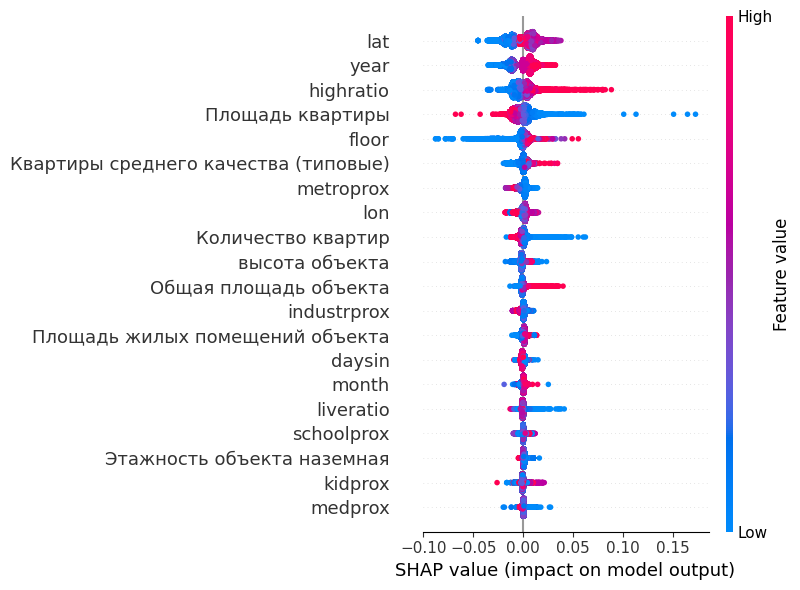

In [426]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(X_test)
shap.summary_plot(explanation, plot_size=[8,6])

## Distillation

In [427]:
class RegressionDistill(nn.Module):
    def __init__(self, in_dim):
        super(RegressionDistill, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(in_dim, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 1),
        )
        
    def forward(self, x):
        out = self.model(x)
        
        return out
    
    
class DataseCustom(torch.utils.data.Dataset):
    def __init__(self, data, data_distill):
        self.data = data
        self.data_distill = data_distill

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return [self.data[idx], self.data_distill[idx]]

In [428]:
data_reg = np.array(data).astype('float32')
data_reg = torch.tensor(data_reg).to(device)

y_for_distill = torch.tensor(xgb.predict(data.drop('pricemetr', axis=1)).reshape(-1, 1)).to(device)

reg_dataset = DataseCustom(data_reg, y_for_distill)
reg_loader = torch.utils.data.DataLoader(reg_dataset, batch_size=256, shuffle=True)

In [429]:
reg_model = RegressionDistill(X.shape[1]).to(device)
optim_reg = optim.AdamW(reg_model.parameters(), lr=3e-4)

epochs = tqdm(range(100))

for _ in epochs:
    for data_x, data_d in reg_loader:
        
        reg_pred = reg_model(data_x[:, :-1])
        
        loss = 0.1 * torch.mean( (reg_pred - data_x[:, -1])**2 ) + torch.mean( (reg_pred - data_d)**2 )
        
        optim_reg.zero_grad()
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(reg_model.parameters(), max_norm=1)
        optim_reg.step()
        
    epochs.set_description(f'{loss.item()}')

0.000167382211657241: 100%|██████████| 100/100 [03:26<00:00,  2.07s/it] 


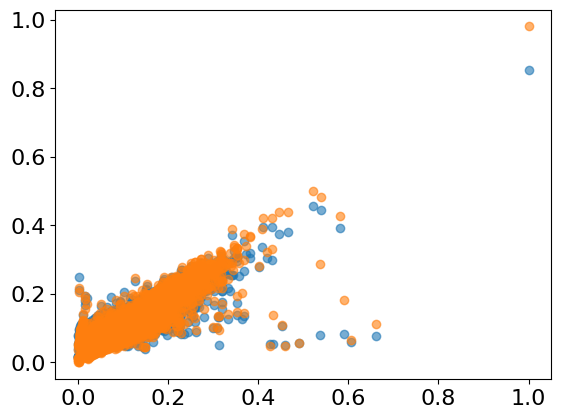

In [430]:
plt.scatter(y_train.values, reg_model(torch.tensor(X_train.values.astype('float32')).to(device)).detach().cpu().numpy().T[0], alpha=0.6)
plt.scatter(y_train.values, xgb.predict(X_train), alpha=0.6)

plt.show()

In [431]:
reg_model.eval()

for param in reg_model.parameters():
    param.requires_grad = False

In [432]:
mean_absolute_percentage_error(y_test.values, xgb.predict(X_test)), r2_score(y_test.values, xgb.predict(X_test))

(0.09556170773857478, 0.8548795308450593)

## Generator

In [500]:
class DataseCustomScenario(torch.utils.data.Dataset):
    def __init__(self, data_wo_x, X_for_sc, y_sc):
        self.data_wo_x = data_wo_x
        self.y_sc = y_sc
        self.X_for_sc = X_for_sc

    def __len__(self):
        return len(self.data_wo_x)

    def __getitem__(self, idx):
        return [self.data_wo_x[idx], self.X_for_sc[idx], self.y_sc[idx]]
    
z = 40 # 0.7
idx_sc = data_unnormalized[data_unnormalized['floor'] > z].index
f = lambda arr: np.array(list(map(lambda y: 0.5 * y + 0.3, arr))) #+  0.1 * np.sin(np.linspace(0, 1, len(arr))*5)

# def f(data):
#     sc = lambda arr: np.array(list(map(lambda y: 0.5 * y, arr))) + 0.1 * np.sin(np.linspace(0, 1, len(arr))*5)
    
#     idx_after_sort = data.loc[idx_sc, 'pricemetr'].sort_values().index
#     y_sc = data.loc[idx_sc, 'pricemetr'].sort_values().values.astype('float32')
#     y_sc = pd.DataFrame(sc(y_sc))
    
#     y_sc.index = idx_after_sort
#     y_sc = y_sc.loc[idx_sc].values.astype('float32')

#     return y_sc

data_wo_x = torch.tensor(data_unnormalized.loc[idx_sc].drop([feat_name, 'pricemetr'], axis=1).values.astype('float32'))

# y_sc = torch.tensor( f(data.loc[idx_sc, 'pricemetr'].values.astype('float32')) ).view(-1, 1)
# y_sc = f(data)
y_sc = np.array(sorted(np.array(list(zip(np.arange(len(idx_sc)), \
                                    data_unnormalized[feat_name].loc[idx_sc].values, \
                                    f(data_unnormalized.loc[idx_sc,'pricemetr']))
                                     )),\
                key=lambda x: x[1]))
y_sc[:, 2] = y_sc[:, 2] + 0.1 *  np.linspace(0, 1, len(y_sc))
y_sc = np.array(sorted(y_sc, key=lambda x: x[0]))
y_sc = torch.tensor(y_sc[:, 2].astype('float32')).view(-1, 1)


X_for_sc = torch.tensor(data_unnormalized.loc[idx_sc, feat_name].values.astype('float32')).view(-1, 1)


sc_dataset = DataseCustomScenario(data_wo_x.unsqueeze(1), X_for_sc, y_sc)
sc_loader = torch.utils.data.DataLoader(sc_dataset, batch_size=256, shuffle=True)

In [593]:
next(iter(sc_loader))[0][:, :, length_cat:]

tensor([[[0.7151, 0.1975, 0.1019,  ..., 0.4405, 0.2748, 0.5664]],

        [[0.4640, 0.1006, 0.8008,  ..., 0.1669, 0.0611, 0.5063]],

        [[0.8949, 0.0762, 0.7654,  ..., 0.7695, 0.1338, 0.4733]],

        ...,

        [[0.4326, 0.0053, 0.5729,  ..., 0.7926, 0.0810, 0.5375]],

        [[0.4326, 0.0474, 0.2875,  ..., 0.7926, 0.3221, 0.5375]],

        [[0.4640, 0.3091, 0.9621,  ..., 0.1669, 0.1263, 0.5063]]])

In [543]:
next(iter(sc_loader))[0][:, 0].T[0]

tensor([29.,  3., 26., 14., 28.,  3.,  0., 26., 27., 14.,  4., 23., 26., 27.,
         2., 10.,  5., 11.,  3., 12., 30.,  2.,  9., 10., 20., 16., 13., 27.,
        15., 26., 29., 30.,  2., 15., 24., 13., 11., 14., 14., 11., 29.,  4.,
        26.,  0.,  0., 23.,  6., 26., 17., 19., 30.,  7.,  9.,  5., 19., 25.,
        18., 18., 28., 22., 25., 30., 20., 23.,  4., 11., 16., 21., 21., 28.,
        27.,  9.,  7., 30.,  6.,  3.,  2., 29., 13.,  3.,  8., 12., 21., 26.,
        15., 28.,  9., 17., 28., 17., 14., 16., 15., 11., 18., 21.,  0., 13.,
        27., 14., 26., 21., 30., 21., 19., 21.,  0., 30.,  2.,  7., 14.,  8.,
         2., 23., 22.,  3.,  5., 15., 29., 21.,  4.,  8., 13., 28., 22.,  7.,
        25., 22., 19., 15., 14., 13.,  9., 26.,  8., 22., 20., 18.,  7.,  6.,
         8., 22.,  1., 22., 13., 26.,  6.,  5.,  3., 23.,  3.,  7.,  0.,  9.,
        12.,  7., 23., 26., 30., 19.,  9., 13., 30., 29.,  6., 18.,  0., 18.,
         4.,  9.,  4., 10., 22., 26., 10., 26., 19., 12.,  1., 2

In [544]:
F.one_hot(next(iter(sc_loader))[0][:, 0].T[1].long(), num_classes=59).size()

torch.Size([256, 59])

In [484]:
# sc = lambda arr: np.array(list(map(lambda y: 0.5 * y + 0.2, arr))) + 0.1 * np.sin(10 * np.linspace(0, 1, len(arr)))

# idx_after_sort = data.loc[idx_sc, 'pricemetr'].sort_values().index
# y_sc = data.loc[idx_sc, 'pricemetr'].sort_values().values.astype('float32')
# y_sc = pd.DataFrame(sc(y_sc))

# y_sc.index = idx_after_sort
# y_sc = y_sc.loc[idx_sc].values.astype('float32')

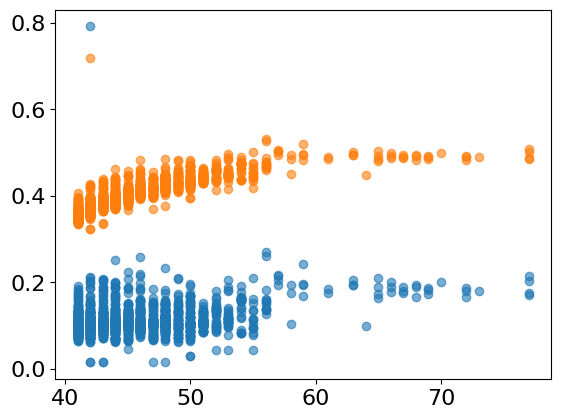

In [487]:
plt.scatter(data_unnormalized['floor'].loc[idx_sc], data_unnormalized.loc[idx_sc, 'pricemetr'], alpha=0.6)
# plt.scatter(data['floor'].loc[idx_sc], f(data.loc[idx_sc,'pricemetr']), alpha=0.6)
plt.scatter(data_unnormalized['floor'].loc[idx_sc], y_sc, alpha=0.6)
# plt.scatter(data['floor'].loc[idx_sc], xgb.predict(synth_df), alpha=0.6)

plt.show()

In [ ]:
# pos = np.where(data.columns == 'floor')[0][0]
# pos

In [492]:
num_classes_all = []

for i in cat_cols_name:
    num_classes_all.append(len(data_unnormalized.loc[:, i].unique()))

In [559]:
sum(num_classes_all)

203

In [839]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.2)
        self.drop2 = nn.Dropout(0.2)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32):
        super(VAE, self).__init__()
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        # self.h_dim_enc = seq_length * hidden_channels
        self.h_dim_enc = 221 * hidden_channels
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_enc))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.SiLU()
        
        
        self.num_classes_for_all = num_classes_all
        self.fc_logits = nn.Linear(203, 203)

    def encode(self, x):
        x = self.enc_conv1(x)
        
        x = self.act(x)
        x = self.enc_res1(x)
        
        x = self.enc_conv2(x)
        x = self.act(x)

        x = self.enc_res2(x)
        x = x.view(x.size(0), -1)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar
    

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


    def decode(self, z):
        # conv_out_length = (self.seq_length) // 4
        x = self.fc_decode(z)
        
        # x = x.view(z.size(0), self.hidden_channels, self.seq_length)
        x = x.view(z.size(0), self.hidden_channels, 221)
        
        x = self.dec_conv1(x)
        x = self.act(x)
        
        x = self.dec_res1(x)
        
        x = self.dec_conv2(x)
        x = self.dec_res2(x)
        
        x = self.dec_conv3(x)    # (BS, 1, 221)
        
        x_num = x[:, :, :length_num]
        x_cat = x[:, :, length_num:]
        
        
        x_cat_logits = torch.split(self.fc_logits(x_cat), self.num_classes_for_all, dim=2)
        
        return F.sigmoid(x_num), x_cat_logits



    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x_num, recon_x_logits = self.decode(z)
        
        return recon_x_num, recon_x_logits, mu, logvar
    
    

def vae_loss(recon_x_num, recon_x_logits, x, X_for_sc, y_sc, mu, logvar, beta, reg_model):
    mse_loss = F.mse_loss(recon_x_num, x[:, :, length_cat:], reduction='mean')
    
    ce_loss = 0
    for i, logits in enumerate(recon_x_logits):
        ce_loss += F.cross_entropy(logits.squeeze(), x[:, :, :length_cat].squeeze(1)[:, i].long(), reduction='mean')
    
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
   
    # left = recon_x.squeeze(1)[:, :pos]
    # right = recon_x.squeeze(1)
    
    generated_labels = []
    # generated_labels = torch.zeros((x.size(0), length_cat)).requires_grad_(True)
    
    for i, logits in enumerate(recon_x_logits):
        probs = F.softmax(logits.squeeze(), dim=1)

        # sample = torch.multinomial(probs, 1).squeeze()
        # print(logits)
        sample = torch.argmax(F.gumbel_softmax(logits.squeeze(), tau=0.5, hard=False, dim=1), dim=-1)
        # print(sample)
        generated_labels.append(sample)
        
        
    generated_labels = torch.stack(generated_labels, dim=1)
    
    result_tensor = torch.cat((X_for_sc, generated_labels, recon_x_num.squeeze(1)), dim=1)
    reg_pred_synth = reg_model(result_tensor)
    ml_loss = torch.mean( (reg_pred_synth - y_sc)**2 )
    
    return (mse_loss + ce_loss) + beta * kl_loss + 2 * ml_loss


def train_vae(model, train_loader, reg_model, num_epochs=500, learning_rate=1e-3, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.0005, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model.train()
    for epoch in epochs:
        epoch_loss = 0
        
        for data, X_for_sc, y_sc in train_loader:
            data = data.to(device)
            
            one_hot_list = []
            for i in range(length_cat):
                one_hot = F.one_hot(data[:, :, :length_cat].squeeze(1)[:, i].long(), num_classes=num_classes_all[i]).float()
                one_hot_list.append(one_hot)
                
            data_cat = torch.cat(one_hot_list, dim=1).to(device).unsqueeze(1)
            data_num = data[:, :, length_cat:]
            x = torch.cat([data_num, data_cat], dim=2)
            
            recon_x_num, recon_x_logits, mu, logvar = model(x)
            
            loss = vae_loss(recon_x_num, recon_x_logits, data, X_for_sc, y_sc, mu, logvar, beta_sch[epoch], reg_model)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        # print(optimizer.param_groups[0]['lr'])
        if epoch % 100 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}')
            
    return losses 

In [840]:
seq_length = 25
input_channels = 1



# Initialize the VAE model
model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=128, hidden_channels=16)

# Train the VAE
losses_vae = train_vae(model_vae, sc_loader, reg_model, num_epochs=300, learning_rate=2e-3)

  0%|          | 0/300 [00:00<?, ?it/s]

Average Loss: 0.0025: 100%|██████████| 300/300 [06:20<00:00,  1.27s/it]


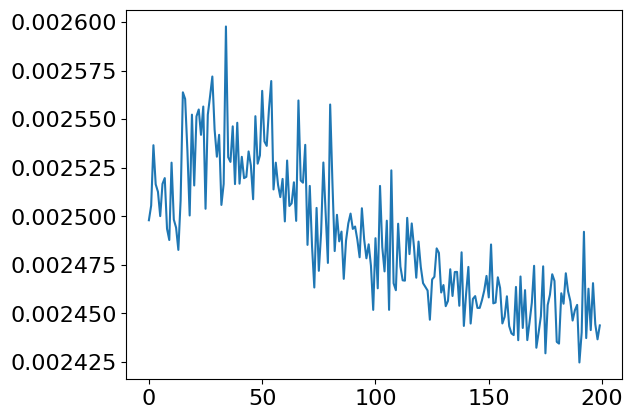

In [841]:
plt.plot(losses_vae[100:])
plt.show()

In [842]:
model_vae.eval()

one_hot_list = []
for i in range(length_cat):
    one_hot = F.one_hot(data_wo_x[:, :length_cat].squeeze(1)[:, i].long(), num_classes=num_classes_all[i]).float()
    one_hot_list.append(one_hot)
    
data_cat = torch.cat(one_hot_list, dim=1).to(device).unsqueeze(1)
data_num = data_wo_x[:, length_cat:].unsqueeze(1)
x = torch.cat([data_num, data_cat], dim=2)

synth_num, synth_cat, mu, logvar = model_vae(x.to(device))
# synth_vae = synth_vae.squeeze(1).detach().cpu()
# left = synth_vae.squeeze(1)[:, :pos]
# right = synth_vae.squeeze(1)[:, pos:]
# synth_vae = torch.cat((left, X_for_sc, right), dim=1)
# synth_df = pd.DataFrame(synth_vae.numpy(), columns=data.columns[:-1])

In [843]:
generated_labels = []
for logits in synth_cat:
    probs = F.softmax(logits.squeeze(), dim=1)
    sample = torch.multinomial(probs, 1).squeeze()
    generated_labels.append(sample)
    
generated_labels = torch.stack(generated_labels, dim=1)

In [844]:
synth_vae = torch.cat([X_for_sc, generated_labels, synth_num.squeeze(1), ], dim=1).detach().cpu().numpy()
synth_df = pd.DataFrame(synth_vae, columns=data.columns[:-1])

In [797]:
# synth_pred = xgb.predict(synth_df)

# plt.scatter(y_test.loc[idx_sc].values, xgb.predict(data.loc[idx_sc]), alpha=0.8, label='Real bad X')
# plt.scatter(y_test.loc[idx_sc].values, synth_pred, alpha=0.8, label='Synth bad X')

# plt.legend()
# plt.show()

/Users/kirillzakharov/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


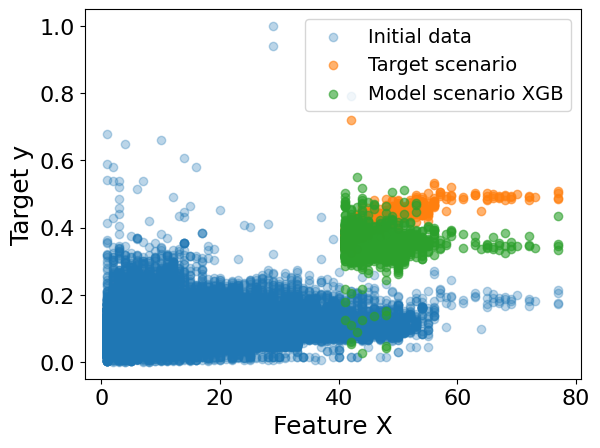

In [847]:
# plt.scatter(X_test['floor'].loc[idx], y_test.loc[idx])
# plt.scatter(X_test['floor'].loc[idx], f(y_test.loc[idx]))
# plt.scatter(X_test['floor'].loc[idx], xgb.predict(synth_df))

# plt.show()


plt.scatter(data_unnormalized['floor'], data_unnormalized['pricemetr'], alpha=0.3, label='Initial data')
plt.scatter(data_unnormalized['floor'].loc[idx_sc], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(data_unnormalized['floor'].loc[idx_sc], xgb.predict(synth_df), alpha=0.6, label='Model scenario XGB')
# plt.scatter(data_unnormalized['floor'].loc[idx_sc], reg_model(torch.tensor(synth_df.values)).numpy().flatten(), alpha=0.6, label='Model scenario NN')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [848]:
data_unnormalized.loc[idx_sc]

,floor,day,количество этажей всего,Этажность объекта подземная,Этажность объекта наземная,Квартиры среднего качества (типовые),month,year,cemetprox,daycos,...,medprox,metroprox,rwprox,schoolprox,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,Площадь квартиры,высота объекта,pricemetr
910,41.0,11,52,2,51,20,6,0,1.000000,0.008127,...,0.180521,0.127741,0.215493,0.119594,0.142216,0.126977,0.195316,0.165203,0.567572,0.090020
913,41.0,11,52,2,51,20,6,0,1.000000,0.008127,...,0.180521,0.127741,0.215493,0.119594,0.142216,0.126977,0.195316,0.358009,0.567572,0.086268
967,44.0,24,52,2,51,20,6,0,1.000000,0.040339,...,0.180521,0.127741,0.215493,0.119594,0.142216,0.126977,0.195316,0.165203,0.567572,0.087538
1108,42.0,17,52,2,51,25,7,0,1.000000,0.158025,...,0.180521,0.127741,0.215493,0.119594,0.142216,0.126977,0.195316,0.290255,0.567572,0.096489
1208,48.0,30,52,2,51,25,7,0,1.000000,0.247506,...,0.180521,0.127741,0.215493,0.119594,0.142216,0.126977,0.195316,0.092012,0.567572,0.088508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251188,42.0,19,42,1,42,4,8,7,0.735708,0.416463,...,0.166714,0.054982,0.039386,0.048843,0.529940,0.295839,0.490861,0.164785,0.411817,0.082379
251214,47.0,19,52,5,48,4,8,7,0.556249,0.416463,...,0.397185,0.039158,0.077652,0.295759,0.214820,0.212793,0.300914,0.477624,0.502067,0.113665
251235,42.0,19,52,5,48,4,8,7,0.556249,0.416463,...,0.397185,0.039158,0.077652,0.295759,0.214820,0.212793,0.300914,0.363028,0.502067,0.106943
251348,47.0,23,48,2,47,4,8,7,0.338942,0.450580,...,0.328137,0.079709,0.182798,0.269803,0.627994,0.370129,0.525955,0.103304,0.449892,0.074654


In [849]:
synth_df

,floor,day,количество этажей всего,Этажность объекта подземная,Этажность объекта наземная,Квартиры среднего качества (типовые),month,year,cemetprox,daycos,...,lon,medprox,metroprox,rwprox,schoolprox,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,Площадь квартиры,высота объекта
0,41.0,11.0,52.0,2.0,51.0,20.0,6.0,0.0,0.999571,0.063234,...,0.259896,0.038684,0.118960,0.422267,0.007828,0.000680,0.001122,0.053615,0.003074,0.917544
1,41.0,11.0,52.0,2.0,51.0,20.0,6.0,0.0,0.948128,0.008061,...,0.186035,0.013001,0.099248,0.553429,0.003978,0.080304,0.034767,0.302203,0.001445,0.935644
2,44.0,24.0,52.0,2.0,51.0,20.0,6.0,0.0,0.986329,0.116864,...,0.460358,0.027794,0.037074,0.206016,0.029386,0.119675,0.045934,0.220168,0.001377,0.877216
3,42.0,17.0,52.0,2.0,51.0,25.0,7.0,0.0,0.999657,0.099026,...,0.443740,0.134876,0.079293,0.089796,0.030456,0.000242,0.000561,0.115788,0.230755,0.462831
4,48.0,30.0,52.0,2.0,51.0,25.0,7.0,0.0,0.998104,0.107477,...,0.430355,0.080230,0.065117,0.117866,0.057016,0.018189,0.044854,0.268187,0.331273,0.443736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1644,42.0,19.0,42.0,1.0,42.0,4.0,8.0,7.0,0.694834,0.328051,...,0.281946,0.017674,0.076873,0.522497,0.006906,0.391458,0.060689,0.561983,0.000009,0.999958
1645,47.0,19.0,52.0,5.0,48.0,4.0,8.0,7.0,0.437918,0.509552,...,0.003053,0.144096,0.245611,0.683426,0.003760,0.000477,0.000144,0.696006,0.000001,0.999992
1646,42.0,19.0,52.0,5.0,48.0,4.0,8.0,7.0,0.363753,0.213835,...,0.005291,0.172056,0.342300,0.723135,0.048745,0.006896,0.003094,0.523848,0.000417,0.998380
1647,47.0,23.0,48.0,2.0,47.0,4.0,8.0,7.0,0.351125,0.328763,...,0.049730,0.099086,0.299576,0.875015,0.008589,0.311035,0.036337,0.695034,0.000008,0.999901


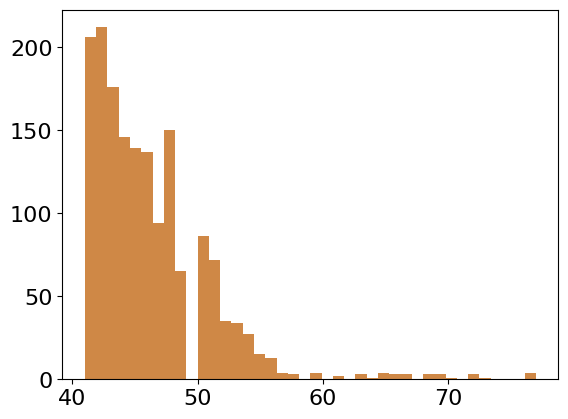

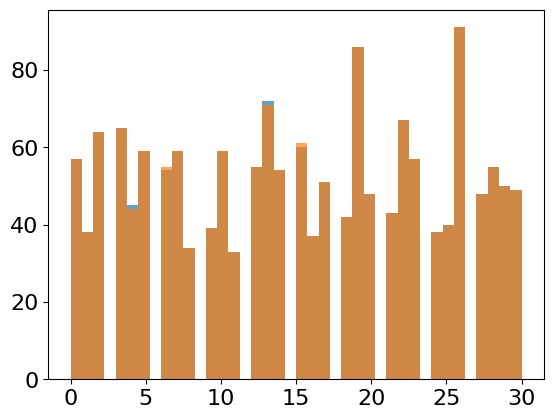

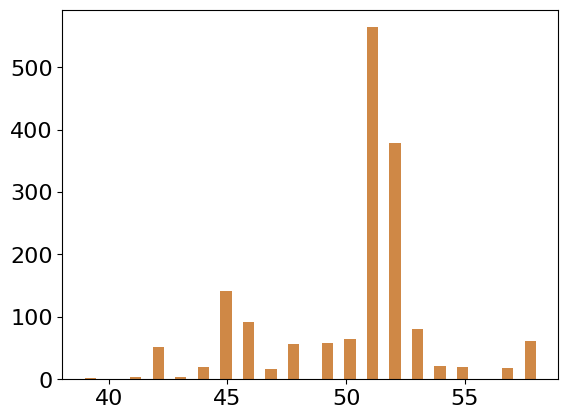

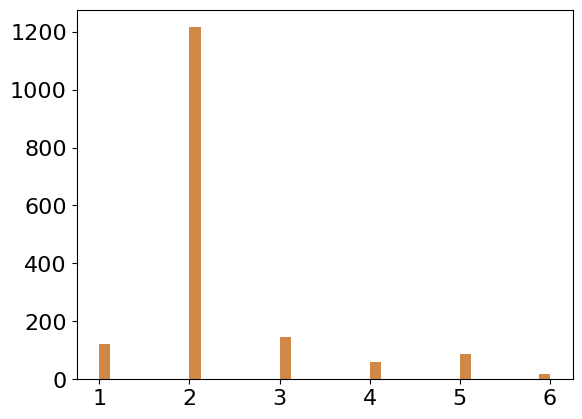

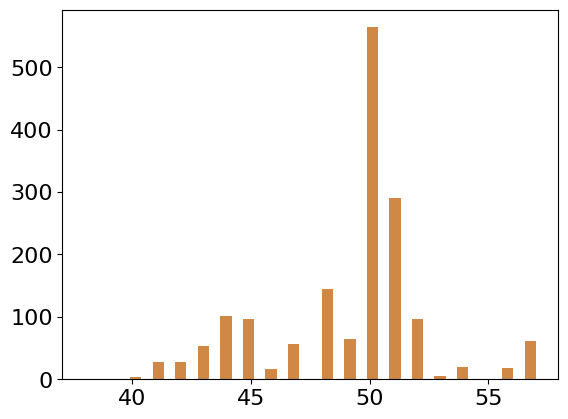

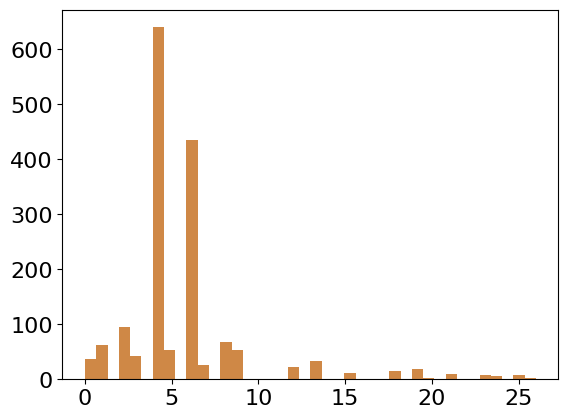

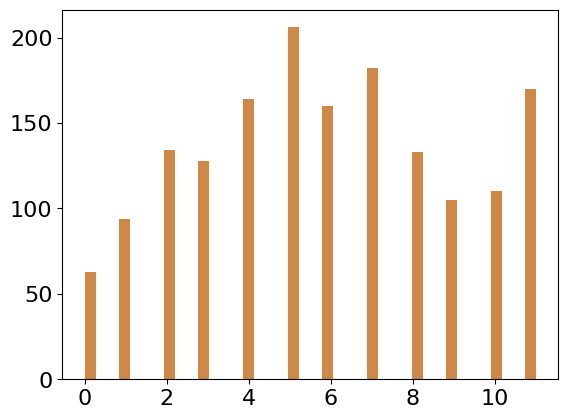

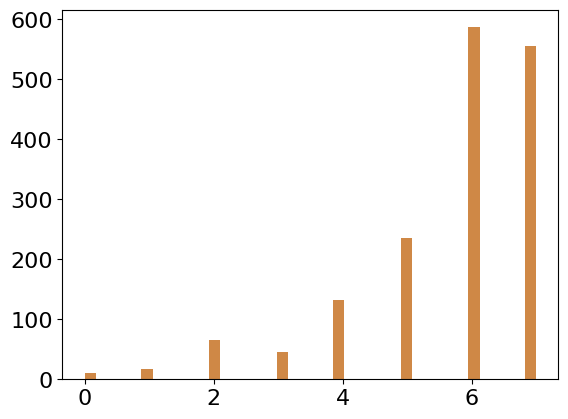

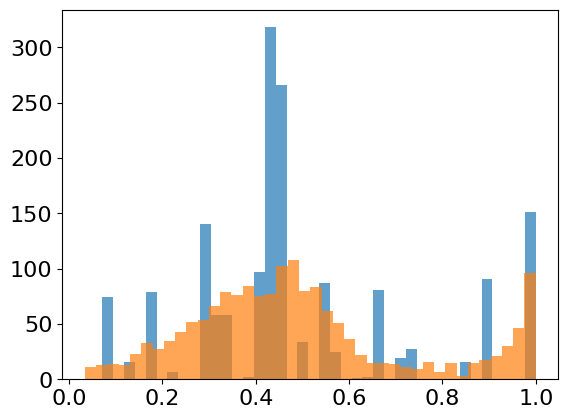

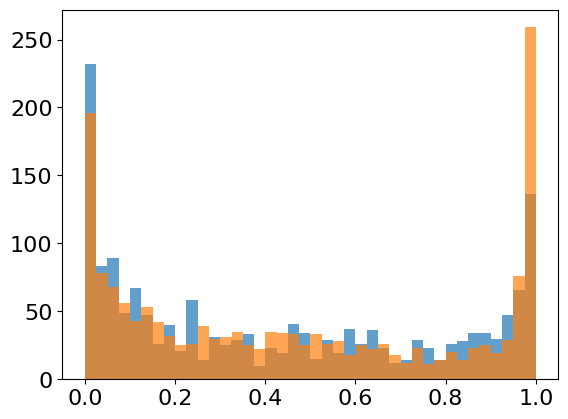

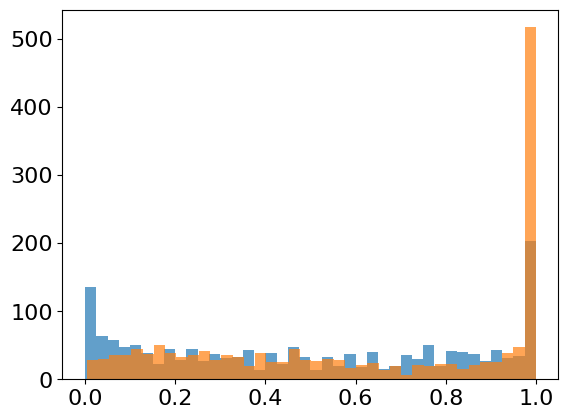

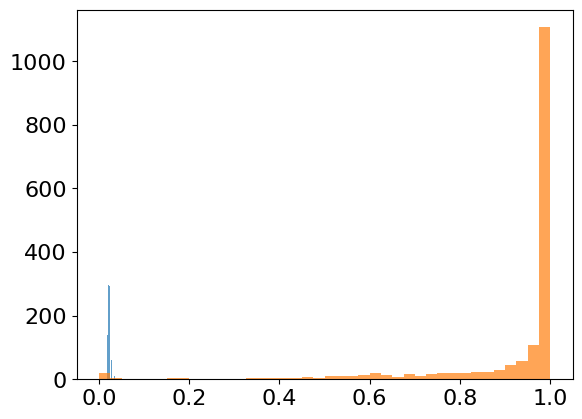

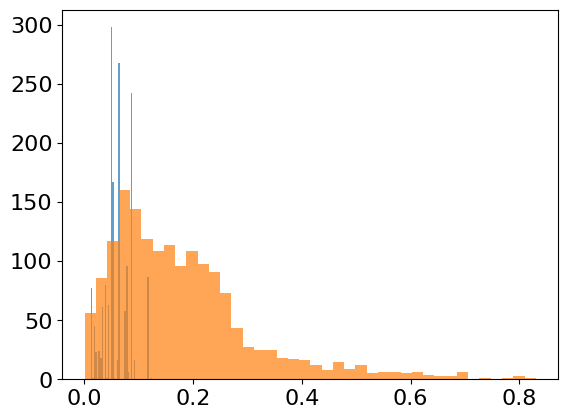

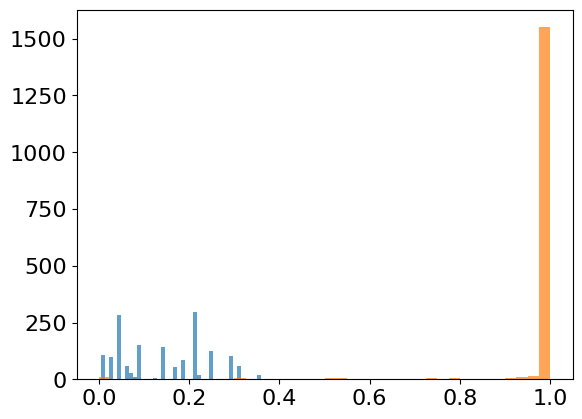

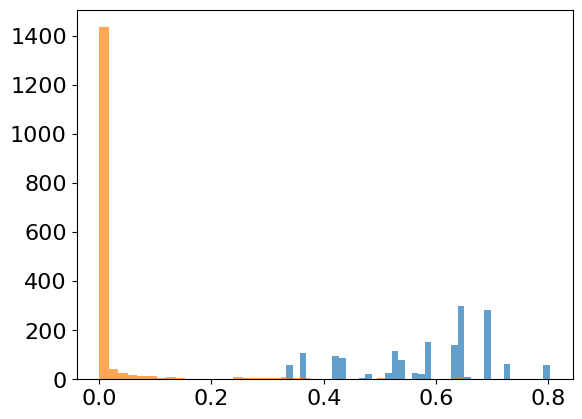

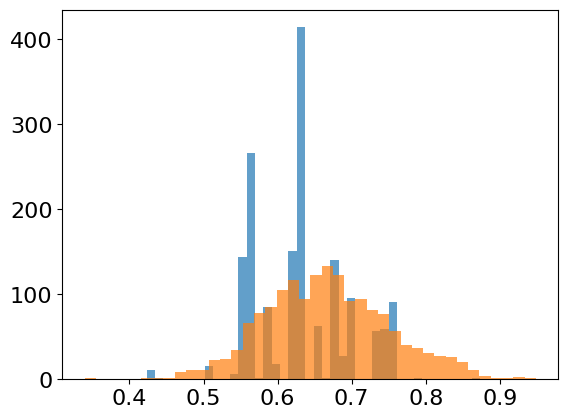

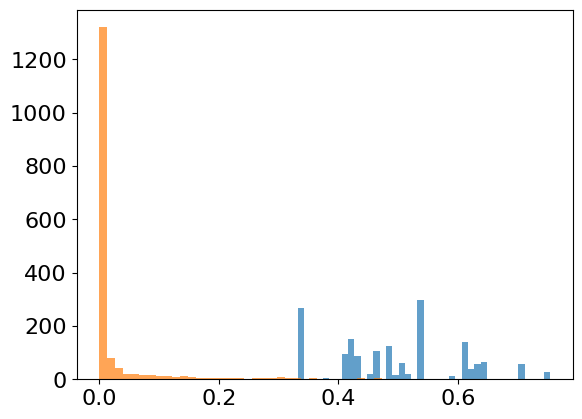

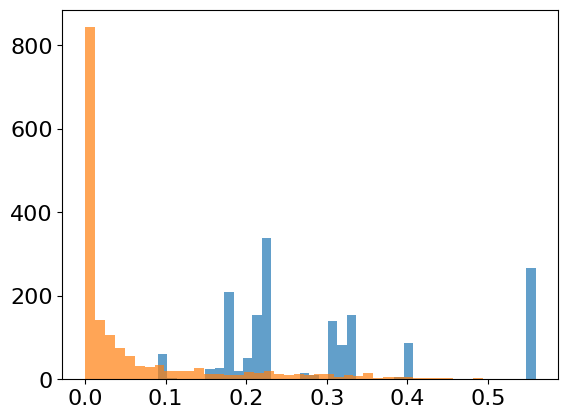

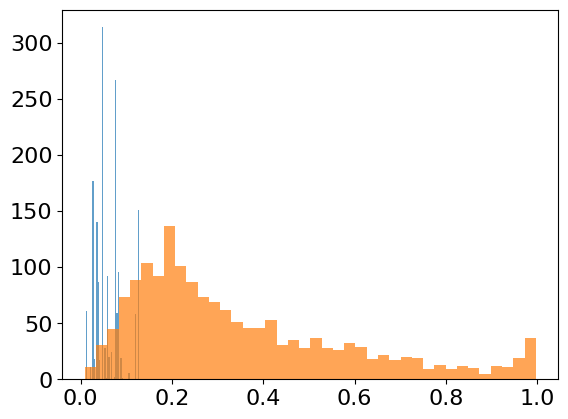

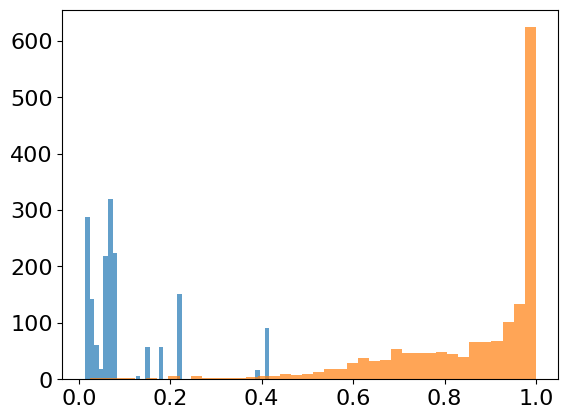

In [850]:
for i in range(0,20):
    plt.hist(data_unnormalized.loc[idx_sc].values[:, i], bins=40, alpha=0.7)
    plt.hist(synth_vae[:, i], bins=40, alpha=0.7)

    plt.show()

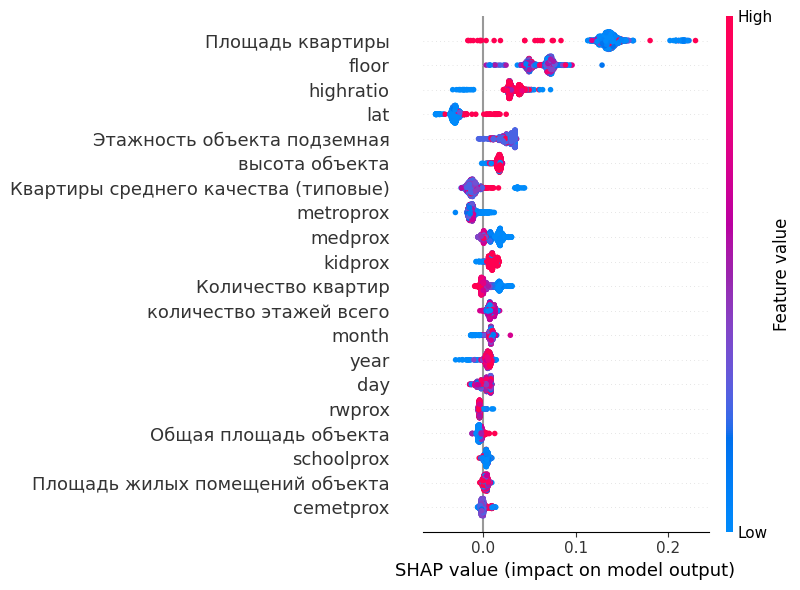

In [851]:
explainer = shap.TreeExplainer(xgb)
# explanation = explainer(data.loc[idx_sc].drop('pricemetr', axis=1))
explanation = explainer(synth_df)
shap.summary_plot(explanation, plot_size=[8,6])

# Second model. Hard scenarios

### Определение значимости признаков

In [172]:
lr = LinearRegression()
lr.fit(X_train, y_train)
reg_coef = lr.coef_

# mean_absolute_percentage_error(y_test.values, lr.predict(X_test)), r2_score(y_test.values, lr.predict(X_test))
# plt.bar(np.arange(len(reg_coef)), reg_coef)
# plt.show()

In [173]:
from sklearn.feature_selection import f_regression, r_regression
from statsmodels.stats.multitest import multipletests

# X - матрица признаков (25 переменных), y - целевая переменная
f_scores, p_values = f_regression(X_train, y_train)

# Выведите результаты
# for i, (f, p) in enumerate(zip(f_scores, p_values)):
#     print(f"Признак {i+1}: F={f:.2f}, p={p:.4f}")

reject, corrected_p, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

In [174]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(X_train)
# shap.summary_plot(explanation, plot_size=[8,6])

In [175]:
feat_order_df = pd.DataFrame(np.array([X_train.columns,\
                                       reg_coef,\
                                       r_regression(X_train, y_train.values.flatten()),\
                                       reject,\
                                       explanation.values.mean(0)]).T)

feat_order_df = feat_order_df.sort_values(by=[1, 2, 3, 4], ascending=False)
feat_order_df

,0,1,2,3,4
3,высота объекта,0.337166,0.3984,True,-0.000654
7,Общая площадь объекта,0.087507,0.26079,True,-0.000574
25,year,0.069003,0.298744,True,-0.000493
12,Квартиры среднего качества (типовые),0.035682,-0.158641,True,0.000079
11,floor,0.035645,0.260261,True,0.000282
4,Этажность объекта подземная,0.023408,0.185099,True,-0.000029
10,lat,0.014337,0.261234,True,0.000083
17,schoolprox,0.009676,0.014598,True,0.000071
9,lon,0.009291,0.231256,True,0.000221
24,month,0.009068,0.001072,False,0.000055


In [176]:
feat_order_names = feat_order_df[0].values
feat_order_names

array(['высота объекта', 'Общая площадь объекта', 'year',
       'Квартиры среднего качества (типовые)', 'floor',
       'Этажность объекта подземная', 'lat', 'schoolprox', 'lon', 'month',
       'kidprox', 'day', 'Площадь жилых помещений объекта', 'daycos',
       'daysin', 'cemetprox', 'medprox', 'liveratio', 'metroprox',
       'rwprox', 'industrprox', 'Площадь квартиры',
       'количество этажей всего', 'Количество квартир', 'highratio',
       'Этажность объекта наземная'], dtype=object)

In [177]:
feat_order_names

array(['высота объекта', 'Общая площадь объекта', 'year',
       'Квартиры среднего качества (типовые)', 'floor',
       'Этажность объекта подземная', 'lat', 'schoolprox', 'lon', 'month',
       'kidprox', 'day', 'Площадь жилых помещений объекта', 'daycos',
       'daysin', 'cemetprox', 'medprox', 'liveratio', 'metroprox',
       'rwprox', 'industrprox', 'Площадь квартиры',
       'количество этажей всего', 'Количество квартир', 'highratio',
       'Этажность объекта наземная'], dtype=object)

In [178]:
feat_order_names = np.delete(feat_order_names, np.where(feat_order_names == 'floor')[0])

In [179]:
feat_order_names

array(['высота объекта', 'Общая площадь объекта', 'year',
       'Квартиры среднего качества (типовые)',
       'Этажность объекта подземная', 'lat', 'schoolprox', 'lon', 'month',
       'kidprox', 'day', 'Площадь жилых помещений объекта', 'daycos',
       'daysin', 'cemetprox', 'medprox', 'liveratio', 'metroprox',
       'rwprox', 'industrprox', 'Площадь квартиры',
       'количество этажей всего', 'Количество квартир', 'highratio',
       'Этажность объекта наземная'], dtype=object)

In [183]:
feat_order_df.sort_values(by=1, ascending=False)

,0,1,2,3,4
3,высота объекта,0.337166,0.3984,True,-0.000654
7,Общая площадь объекта,0.087507,0.26079,True,-0.000574
25,year,0.069003,0.298744,True,-0.000493
12,Квартиры среднего качества (типовые),0.035682,-0.158641,True,0.000079
11,floor,0.035645,0.260261,True,0.000282
4,Этажность объекта подземная,0.023408,0.185099,True,-0.000029
10,lat,0.014337,0.261234,True,0.000083
17,schoolprox,0.009676,0.014598,True,0.000071
9,lon,0.009291,0.231256,True,0.000221
24,month,0.009068,0.001072,False,0.000055


In [ ]:
# def identify_feat_order(sc_type: int):
#     feat_order_df = pd.DataFrame(np.array([X_train.columns,\
#                                        reg_coef,\
#                                        r_regression(X_train, y_train.values.flatten()),\
#                                        reject,\
#                                        explanation.values.mean(0)]).T)

#     if sc_type == 1:
#         feat_order_df = feat_order_df.sort_values(by=[1, 2, 3, 4], ascending=False)
        
#     elif sc_type == -1:
#         feat_order_df = feat_order_df.sort_values(by=[1, 2, 3, 4], ascending=True)

In [ ]:
# import statsmodels.api as sm
# from statsmodels.formula.api import ols

# X_train_ols = sm.add_constant(X_train)
# ols_model = sm.OLS(y_train, X_train_ols)
# res_ols = ols_model.fit()
# print(res_ols.summary())
# res_ols.params

https://www.geeksforgeeks.org/interpreting-the-results-of-linear-regression-using-ols-summary/

In [ ]:
# sm.stats.anova_lm(res_ols, typ=1)

In [1262]:
# from scipy.stats import spearmanr

# # Для каждой количественной переменной:
# for col in ['Площадь квартиры']:  # замените на список количественных переменных
#     corr, p = spearmanr(data[col], data['pricemetr'])
#     print(f"{col}: Spearman rho={corr:.2f}, p-value={p:.4f}")
    
    
# from scipy.stats import kruskal

# # Пример: df содержит 25 независимых переменных и одну зависимую 'target'
# # Для каждой категориальной переменной:
# for col in ['day', 'высота объекта']:  # замените на список категориальных переменных
#     groups = [group['pricemetr'].values for _, group in data.groupby(col)]
#     stat, p = kruskal(*groups)
#     print(f"{col}: H-statistic={stat:.2f}, p-value={p:.4f}")

### Создание сценария

In [46]:
feature_name = 'floor'

X_exp = data[['Общая площадь объекта', 'highratio', 'Этажность объекта наземная', 'Квартиры среднего качества (типовые)', feature_name]]
y_exp = data[['pricemetr']]

In [47]:
xgb_exp = XGBRegressor()
xgb_exp.fit(X_exp, y_exp)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [48]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_exp[[feature_name]], y_exp)
lr.coef_

array([[0.39289003]])

In [50]:
z = 0.7
idx_sc = X_exp[X_exp[feature_name] > z].index
f = lambda arr: np.array(list(map(lambda y: 0.7 * y + 0.3, arr)))

y_sc = np.array(sorted(np.array(list(zip(np.arange(len(idx_sc)), X_exp.loc[idx_sc, feature_name].values.flatten(), \
                                f(y_exp.values.flatten())))), key=lambda x: x[1]))
y_sc[:, 2] = y_sc[:, 2] + 0.1 * np.linspace(0, 1, len(y_sc))
y_sc = np.array(sorted(y_sc, key=lambda x: x[0]))
y_sc = torch.tensor(y_sc[:, 2].astype('float32')).view(-1, 1)

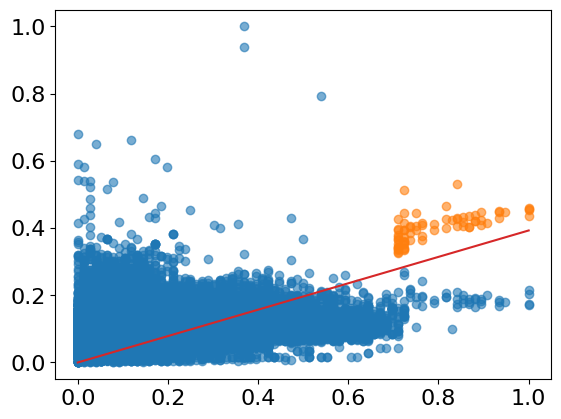

In [51]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6)
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6)
plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.show()

In [52]:
feat_col_idx = np.where(X_exp.columns == feature_name)[0].item()

In [53]:
num_cols_name = ['Общая площадь объекта', 'highratio']
cat_cols_name = ['Этажность объекта наземная', 'Квартиры среднего качества (типовые)']

In [54]:
from functools import partial

In [167]:
def objective(trial, i):
    num_arr = [] 
    for col in num_cols_name:
        num_arr.append(trial.suggest_float(f"{col}", 0, 1, step=0.001))
        
    cat_arr = []
    for col in cat_cols_name:
        cat_arr.append(trial.suggest_categorical(f"{col}", X_exp[col].unique()))

    prediction = xgb_exp.predict([np.hstack([num_arr, cat_arr, [X_exp.loc[idx_sc].iloc[i, -1]]])])    
        
    objective = (prediction - y_sc.numpy()[i])**2
    # objective = (prediction - y.loc[idx_sc].iloc[0])**2
    if trial.should_prune():
            raise optuna.TrialPruned()
    
    return objective


scenario_df = pd.DataFrame(columns=np.hstack([num_cols_name, cat_cols_name]))
steps = tqdm(range(len(y_sc)))
optuna.logging.set_verbosity(optuna.logging.WARNING)

for i in steps:
    objective_with_args = partial(objective, i=i)
    study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
    study.optimize(objective_with_args, n_trials=100)
    
    one_point_df = pd.DataFrame(study.best_params.items()).T.iloc[[1]].rename(columns=dict(zip(np.arange(4), np.hstack([num_cols_name, cat_cols_name]))))
    
    scenario_df = pd.concat([scenario_df, one_point_df])

100%|██████████| 70/70 [01:23<00:00,  1.19s/it]


In [168]:
# scenario_df = pd.DataFrame(study.best_params.items()).T
# scenario_df.columns = scenario_df.iloc[0]
# scenario_df = scenario_df.iloc[1:]
# scenario_df = pd.DataFrame(columns=np.hstack([num_cols_name, cat_cols_name]))
# scenario_df = pd.concat([scenario_df, pd.DataFrame(study.best_params.items()).T.iloc[[1]].rename(columns=dict(zip(np.arange(4), np.hstack([num_cols_name, cat_cols_name]))))])

In [169]:
scenario_df = scenario_df.reset_index(drop=True)
scenario_df = pd.concat([scenario_df, X_exp.loc[idx_sc, feature_name].reset_index(drop=True)], axis=1).astype(float)
prediction_exp = xgb_exp.predict(scenario_df)

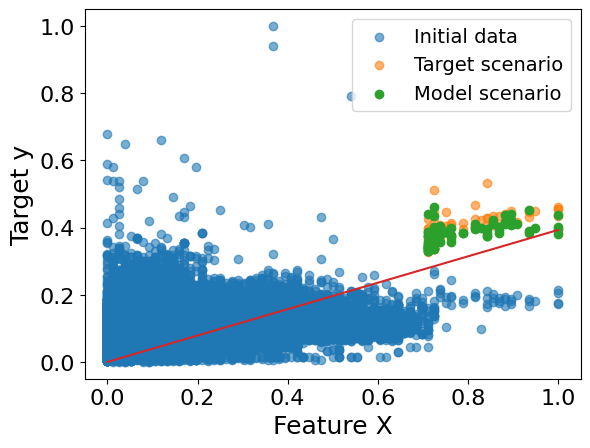

In [170]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(X_exp.loc[idx_sc, feature_name], prediction_exp, label='Model scenario')
plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [143]:
def objective_cat(trial, col, i):
    feat = trial.suggest_categorical(f"{col}", X_exp[col].unique())
    
    X_exp_feat = X_exp.loc[idx_sc].iloc[i].copy()
    X_exp_feat[col] = feat
    
    prediction = xgb_exp.predict([X_exp_feat.values.T])    
    objective = (prediction - y_sc.numpy()[i])**2

    if trial.should_prune():
            raise optuna.TrialPruned()
    
    return objective

def objective_num(trial, col, i):
    feat = trial.suggest_float(f"{col}", 0, 1, step=0.001)
    
    X_exp_feat = X_exp.loc[idx_sc].iloc[i].copy()
    X_exp_feat[col] = feat
    
    prediction = xgb_exp.predict([X_exp_feat.values.T])    
    objective = (prediction - y_sc.numpy()[i])**2

    if trial.should_prune():
            raise optuna.TrialPruned()
    
    return objective



all_cat_df = []
all_num_df = []
all_prediction_err = []

for col in cat_cols_name:
    feat_df = []
    scenario_df = X_exp.loc[idx_sc].copy()
    steps = tqdm(range(len(y_sc)))
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    for i in steps:
        objective_with_args = partial(objective_cat, col=col, i=i)
        study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
        study.optimize(objective_with_args, n_trials=40)
        
        feat_df.append(study.best_params[col])
        
    scenario_df[col] = feat_df
    prediction_exp = xgb_exp.predict(scenario_df)
    
    all_cat_df.append(scenario_df)
    all_prediction_err.append(np.mean((prediction_exp - y_sc.numpy().flatten())**2))
    
    
for col in num_cols_name:
    feat_df = []
    scenario_df = X_exp.loc[idx_sc].copy()
    steps = tqdm(range(len(y_sc)))
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    for i in steps:
        objective_with_args = partial(objective_num, col=col, i=i)
        study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
        study.optimize(objective_with_args, n_trials=40)
        
        feat_df.append(study.best_params[col])
        
    scenario_df[col] = feat_df
    prediction_exp = xgb_exp.predict(scenario_df)
    
    all_num_df.append(scenario_df)
    all_prediction_err.append(np.mean((prediction_exp - y_sc.numpy().flatten())**2))

100%|██████████| 70/70 [00:05<00:00, 13.00it/s]


In [144]:
all_prediction_err

[0.04188736, 0.04744023, 0.038200885, 0.03621314]

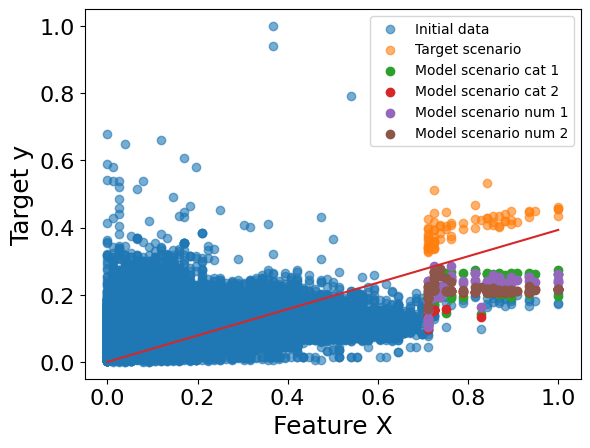

In [151]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(X_exp.loc[idx_sc, feature_name], xgb_exp.predict(all_cat_df[0]), label='Model scenario cat 1')
plt.scatter(X_exp.loc[idx_sc, feature_name], xgb_exp.predict(all_cat_df[1]), label='Model scenario cat 2')
plt.scatter(X_exp.loc[idx_sc, feature_name], xgb_exp.predict(all_num_df[0]), label='Model scenario num 1')
plt.scatter(X_exp.loc[idx_sc, feature_name], xgb_exp.predict(all_num_df[1]), label='Model scenario num 2')

plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend(fontsize=10)
plt.show()

In [163]:
from itertools import product

In [166]:
list(product(cat_cols_name, num_cols_name))

[('Этажность объекта наземная', 'Общая площадь объекта'),
 ('Этажность объекта наземная', 'highratio'),
 ('Квартиры среднего качества (типовые)', 'Общая площадь объекта'),
 ('Квартиры среднего качества (типовые)', 'highratio')]

In [ ]:
# for col in cat_cols_name:
#     trial.suggest_categorical(f"{col}", X_exp[col].unique())
    
#     prediction = xgb_exp.predict([np.hstack([num_arr, cat_arr, [X_exp.loc[idx_sc].iloc[i, -1]]])])    
        
#     objective = (prediction - y_sc.numpy()[i])**2
#     # objective = (prediction - y.loc[idx_sc].iloc[0])**2
#     if trial.should_prune():
#         #     raise optuna.TrialPruned()
    
#     return objective

In [70]:
cat_cols_name[0]

'Этажность объекта наземная'

In [77]:
col_id = np.where(X_exp.columns == cat_cols_name[0])[0][0]

In [78]:
col_id

2

In [72]:
X_exp.loc[:, X_exp.columns != cat_cols_name[0]]

,Общая площадь объекта,highratio,Квартиры среднего качества (типовые),floor
0,0.039611,0.016714,0.877598,0.065789
1,0.039611,0.016714,0.877598,0.105263
2,0.050667,0.024355,0.877598,0.000000
3,0.050667,0.024355,0.877598,0.026316
4,0.144406,0.029692,0.877598,0.144737
...,...,...,...,...
251602,0.135337,0.016308,0.122259,0.026316
251603,0.347790,0.022981,0.122259,0.092105
251604,0.347790,0.022981,0.122259,0.131579
251605,0.135337,0.016308,0.122259,0.039474


In [67]:
np.mean((prediction_exp - y_sc.numpy().flatten())**2)

0.00074681884

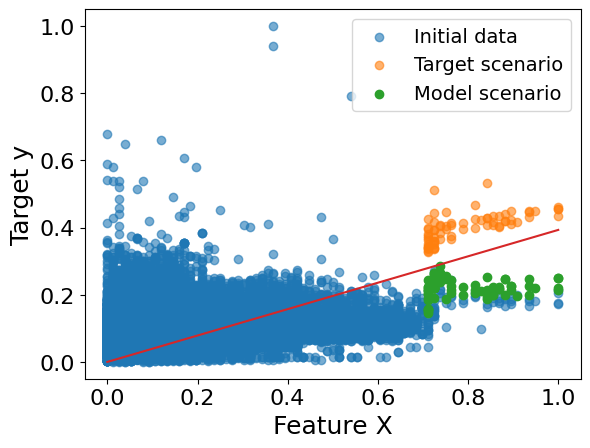

In [137]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(X_exp.loc[idx_sc, feature_name], prediction_exp, label='Model scenario')
plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [58]:
# import gym
# from stable_baselines3 import PPO

# # Custom environment for scenario generation
# class ScenarioEnv(gym.Env):
#     def __init__(self):
#         self.action_space = gym.spaces.Box(low=-1, high=1, shape=(4,))  # Scenario parameters
#         self.observation_space = gym.spaces.Box(low=0, high=1, shape=(10,))  # State features
#         self.state = 0.0

#     def step(self, action):
#         # Modify scenario parameters (action)
#         # Run simulation and compute reward (e.g., realism score + challenge)
#         reward = self._compute_reward(action)
#         done = True  # Scenario complete
#         return self.state, reward, done, {}

#     def reset(self):
#         # Initialize with base scenario
#         return self.state

#     def _compute_reward(self, action):
#         # print(action)
#         # Realism (adversarial score) + challenge (model failure)
#         if np.mean(action) < 0.5:
#             return 0
#         else:
#             return 1
        

# env = ScenarioEnv()
# model = PPO("MlpPolicy", env, verbose=1)
# model.learn(total_timesteps=10000)